# COM4509/6509 Assignment 2024

Hello, this is the programming assignment for *Machine Learning and Adaptive Intelligence*. This is worth 50% of the module grade, the remaining 50% will be assessed via the formal exam.

**Deadline: 13th December 2024, 23:59**

Please submit well before the deadline as there may be delays in the submission. Submission will be via Blackboard.

There are 2 parts to this assignment, covering different portions of the course. Both parts are worth 50 marks to give a combined total of 100 marks. Both contain a set of questions which will ask you to implement various machine learning algorithms that are covered throughout the course. You will receive marks for the correctness of your implementations, text based responses to certain questions and the quality of your code. Each question indicates how many marks are available.

### Use of unfair means and Generative AI

For this assignment **you must not use code/text produced by generative AI, that is created using a prompt**. The 'autocomplete' feature in colab can still be used.

This is an individual assignment, while you may discuss this with your classmates, **please make sure you submit your own code**. You are allowed to use code from the labs as a basis of your submission.

The university's policy on the use of GenAI is on [this page](https://www.sheffield.ac.uk/study-skills/digital/generative-ai/assessment).

"Any form of unfair means is treated as a serious academic offence and action may be taken under the Discipline Regulations." (from the students Handbook).

### Assignment help

If you are stuck and unsure what you need to do then please ask either in the lectures, labs or on the discussion board. There is a limit to what help we can provide but where possible we will give general guidance with how to proceed.

We are happy for you to discuss the assignment with other students but your code and test answers **must** be your own.

### What to submit

- You need to submit a **pdf** of your notebook *and* the **notebook**. Please name them:

```
assignment_[username].ipynb
assignment_[username].pdf
```
replacing `[username]` with your username, e.g. `abc18de`.

- **Please execute the cells before your submission**, so we can see the results in the pdf. The best way to get a pdf is using Jupyter Notebook locally but if you are using Google Colab and are unable to download it to use Jupyter then you can use the Google Colab *file $\rightarrow$ print* to get a pdf copy.
- **Please do not upload** the data files used in this Notebook. We just want the python notebook *and the pdf*.

### Late submissions

We follow the department's guidelines about late submissions, Undergraduate [handbook link](https://sites.google.com/sheffield.ac.uk/comughandbook/your-study/assessment/late-submission). PGT [handbook link](https://sites.google.com/sheffield.ac.uk/compgtstudenthandbook/home/your-study/assessment/late-submission).


<hr>

# Part 2: Neural networks, Dimensionality reduction and Clustering

This is the *second* of the two parts, accounting for the other 50 marks of the overall coursework mark.
Attempt as much of this as you can, each of the questions are self-contained and contain some easier and harder bits so even if you can't complete Question 1 straight away then you may still be able to progress with the other questions.

## Overview
This part of the assignment will cover:
- Q1: Classification and neural networks (lectures 5 and 6)
- Q2: Dimensionality reduction and clustering (lectures 7 and 8)

### Allowed libraries
For this part we are looking for you to demonstrate what you have learned in this module and so we will be restricting what libraries you can use to
- Numpy and Scipy
- Matplotlib
- PyTorch
- Scikit-Learn (for simple models)

### Assessment Criteria

- The marks for this part are distributed as follows:
    - **Q1**: 28 marks
    - **Q2**: 17 marks
    - **Code quality**: 5 marks
        - Marks for code quality does not cover the correctness of your answers to each section but rather the style and clarity of your code. You should aim to avoid repetition of code, have clear but concise comments and appropriately named variables.
- You'll get marks for correct code that does what is asked and for text based answers to particular points. We are not overly concerned with model performance but you should still aim to get the best results you can for your chosen approaches. You should make sure any figures are plotted properly with axis labels and figure legends.

If you are unsure about how to proceed then please ask during the lectures/labs or on the discussion board.



## 2. Denoising Autoencoder [17 marks]

### The CIFAR-10 dataset
In this assignment, we will work on the CIFAR-10 dataset collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton from the University of Toronto. This dataset consists of 60,000  colour images in 10 classes, with 6,000 images per class. Each sample is a 3-channel colour images of 32x32 pixels in size. There are 50,000 training images and 10,000 test images.

### 2.1: Data loading and manipulation [3 marks]

**2.1a** Using the PyTorch Torchvision datasets, download both the training and test data of the CIFAR-10 dataset. If you find it more convenient, you may download them from a different source the Torchvision. For an example, please see the lab on Convolutional Neural Networks.

In [17]:
import torch 
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np

batch_size = 64

transform = transforms.Compose([transforms.ToTensor()])

trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


**2.1b** Add random noise to all training and test data to generate noisy dataset, e.g., by torch.randn(), with a scaling factor scale, e.g., original image + scale * torch.randn(), and normalise/standardise the pixel values to the original range, e.g., using torch.clip(). You may choose any scale value between 0.2 and 0.5.

There are 2 ways to apply these random transformations using the latest version of Torchvision. Either are acceptable as long as the correct noise is applied.
- In the newer verions, PyTorch has introduced v2 transformations which includes directly a `GaussianNoise([mean, sigma, clip])` transformation (please see [here](https://pytorch.org/vision/master/transforms.html#color) for more details).
- If you are not using the vv2 transformations then random transformation can be applied using a `Lambda` [transform](https://pytorch.org/vision/stable/transforms.html) when composing the load data transform, which looks a little like this:  
`transforms.Lambda(lambda x: x + ..... )`

Note: Before generating the random noise, you MUST set the random seed to your UCard number XXXXXXXXX for reproducibility, e.g., using torch.manual_seed(). This seed needs to be used for all remaining code if there is randomness, for reproducibility.

You may want to create separate dataloaders for the noisy and clear images but make sure they are **not shuffling the data** so that correct pair of images are being given as input and desired output.

In [8]:
torch.manual_seed(240167723)
scale = 0.2

transform_original = transforms.Compose([transforms.ToTensor()])
transform_noisy = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: torch.clamp(x + torch.randn(x.size()) * scale, 0.0, 1.0))])
# transform_noisy = transforms.Compose([transforms.ToTensor(),transforms.GaussianNoise(mean=0.0, std=scale, clip=(0.0, 1.0))])

def load_data(transform_original, transform_noisy, batch_size=64):
    original_trainset = CIFAR10(root='./data', train=True, download=True, transform=transform_original)
    original_trainloader = DataLoader(original_trainset, batch_size=batch_size, shuffle=False, num_workers=2)

    original_testset = CIFAR10(root='./data', train=False, download=True, transform=transform_original)
    original_testloader = DataLoader(original_testset, batch_size=batch_size, shuffle=False, num_workers=2)


    noisy_trainset = CIFAR10(root='./data', train=True, download=True, transform=transform_noisy)
    noisy_trainloader = DataLoader(noisy_trainset, batch_size=batch_size, shuffle=False, num_workers=2)

    noisy_testset = CIFAR10(root='./data', train=False, download=True, transform=transform_noisy)
    noisy_testloader = DataLoader(noisy_testset, batch_size=batch_size, shuffle=False, num_workers=2)

    return original_trainloader, original_testloader, noisy_trainloader, noisy_testloader

original_trainloader, original_testloader, noisy_trainloader, noisy_testloader = load_data(transform_original, transform_noisy, batch_size=64) # Load the data


Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


**2.1c** Show 10 pairs of original and noisy images.

Original shape: torch.Size([64, 3, 32, 32])


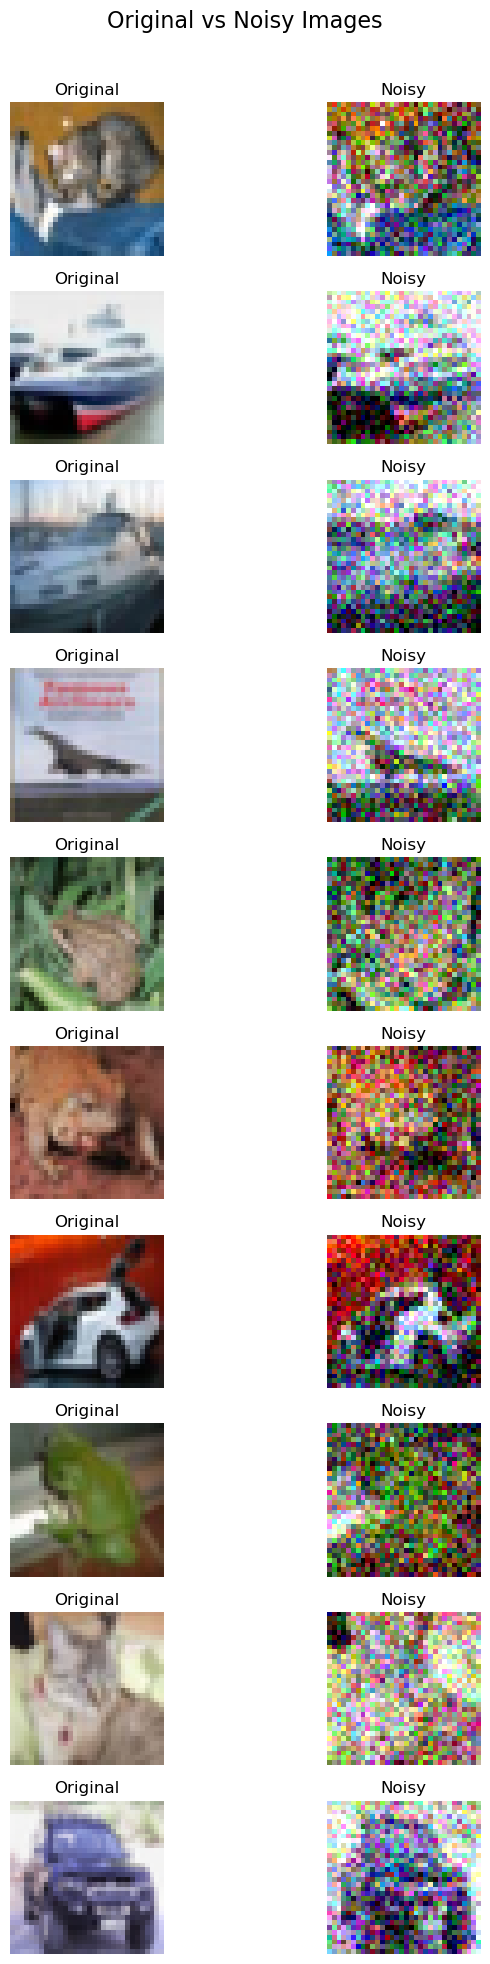

In [9]:
import matplotlib.pyplot as plt

num_pairs=10
# Get one batch of clear and noisy images
original_images, _ = next(iter(original_testloader))
noisy_images, _ = next(iter(noisy_testloader))

# Prepare the figure
fig, axes = plt.subplots(num_pairs, 2, figsize=(8, 2 * num_pairs))
fig.suptitle("Original vs Noisy Images", fontsize=16)

print("Original shape:", original_images.shape)
for i in range(num_pairs):
    original_img = original_images[i].permute(1, 2, 0).numpy()
    noisy_img = noisy_images[i].permute(1, 2, 0).numpy()

    # Display the images
    axes[i, 0].imshow(original_img)
    axes[i, 0].axis("off")
    axes[i, 0].set_title("Original")

    axes[i, 1].imshow(noisy_img)
    axes[i, 1].axis("off")
    axes[i, 1].set_title("Noisy")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### 2.2 Applying a Denoising Autoencoder to the modified CIFAR10 [10 marks]

This question uses both the original and noisy CIFAR-10 datasets (all 10 classes).
Read about denoising autoencoders at [Wikipedia](https://en.wikipedia.org/wiki/Autoencoder) and this [short introduction](https://towardsdatascience.com/denoising-autoencoders-explained-dbb82467fc2) or any other sources you like.

**2.2a** Modify the autoencoder architecture so that it takes colour images as input (i.e., 3 input channels).

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),  # Input is 3 channels (RGB)
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(512, 256 * 4 * 4),
            nn.ReLU(),
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),  # Output is 3 channels (RGB)
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
        


**2.2b** Training: feed the noisy training images as input to the autoencoder defined above; use a loss function that computes the reconstruction error between the output of the autoencoder and the respective original images.

In [15]:
def train_autoencoder(model, noisy_trainloader, original_trainloader, num_epochs=10):
    # Initialize the model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Define loss and optimizer
    loss_func = nn.MSELoss()  # Mean Squared Error Loss
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    num_epochs = 10
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for noisy_images, original_images in zip(noisy_trainloader, original_trainloader):
            noisy_images, original_images = noisy_images[0].to('cuda'), original_images[0].to('cuda')
            
            outputs = model(noisy_images)
            loss = loss_func(outputs, original_images)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(noisy_trainloader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    # Save the trained model
    torch.save(model.state_dict(), 'autoencoder.pth')
    return model

# Initialize the model
model = Autoencoder()

# Train the autoencoder
autoencoder = train_autoencoder(model, noisy_trainloader, original_trainloader, num_epochs=10)

Epoch [1/10], Loss: 0.0219
Epoch [2/10], Loss: 0.0119
Epoch [3/10], Loss: 0.0098
Epoch [4/10], Loss: 0.0087
Epoch [5/10], Loss: 0.0081
Epoch [6/10], Loss: 0.0077
Epoch [7/10], Loss: 0.0073
Epoch [8/10], Loss: 0.0070
Epoch [9/10], Loss: 0.0068
Epoch [10/10], Loss: 0.0066


**2.2c** Testing: evaluate the autoencoder trained in 2.2b on the test datasets (feed noisy images in and compute reconstruction errors on original clean images. Find the worst denoised 20 images (those with the largest reconstruction errors) in the test set and show them in pairs with the original images (40 images to show in total).

/tmp/ipykernel_559274/3516089417.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('autoencoder.pth'))


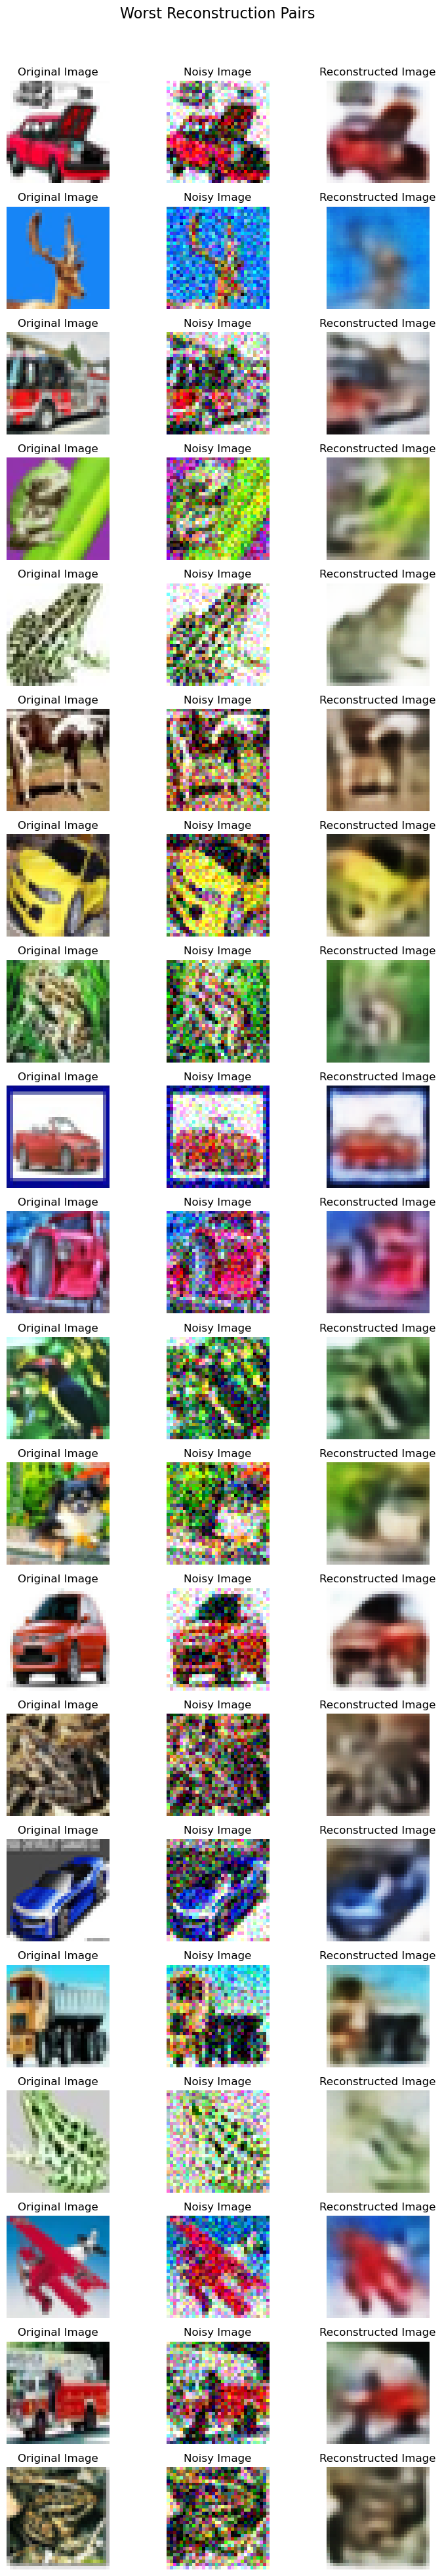

In [18]:
# Load the trained model for testing
model.load_state_dict(torch.load('autoencoder.pth'))
num_worst = 20

images = {}
def test_autoencoder(model, noisy_testloader, original_testloader):
    # Testing and evaluation
    model.eval()
    reconstruction_errors = []
    noisy_images_list = []
    original_images_list = []
    reconstucted_images = []

    with torch.no_grad():
        for (noisy_images, _), (original_images, _) in zip(noisy_testloader, original_testloader):
        # for _ in range(len(noisy_test_loader)):
            if noisy_images.size(0) != original_images.size(0):
                break  # Ensure batch sizes match

            noisy_images, original_images = noisy_images.to('cuda'), original_images.to('cuda')
            outputs = model(noisy_images)

            # Compute reconstruction errors (MSE per image)
            errors = torch.mean((outputs - original_images) ** 2, dim=[1, 2, 3])
            reconstruction_errors.extend(errors.cpu().numpy())
            noisy_images_list.append(noisy_images.cpu())
            original_images_list.append(original_images.cpu())
            reconstucted_images.append(outputs.cpu())

    # Flatten image lists
    noisy_images_flat = torch.cat(noisy_images_list, dim=0)
    original_images_flat = torch.cat(original_images_list, dim=0)
    reconstucted_images_flat = torch.cat(reconstucted_images, dim=0)

    # Find indices of the worst images
    reconstruction_errors = np.array(reconstruction_errors)

    images["noisy_images"] = noisy_images_flat
    images["original_images"] = original_images_flat
    images["reconstucted_images"] = reconstucted_images_flat

    return reconstruction_errors

reconstruction_errors = test_autoencoder(model, noisy_testloader, original_testloader)
worst_indices = np.argsort(-reconstruction_errors)[:num_worst]


# Display the worst images
fig, axes = plt.subplots(num_worst, 3, figsize=(8, 2 * num_worst))
fig.suptitle("Worst Reconstruction Pairs", fontsize=16)

for i, idx in enumerate(worst_indices):
    noisy_img = images["noisy_images"][idx].permute(1, 2, 0).numpy()
    original_img = images["original_images"][idx].permute(1, 2, 0).numpy()
    reconst_img = images["reconstucted_images"][idx].permute(1, 2, 0).numpy()


    # Clip values to range [0, 1]
    noisy_img = np.clip(noisy_img, 0, 1)
    original_img = np.clip(original_img, 0, 1)
    reconst_img = np.clip(reconst_img, 0, 1)

    # Plot noisy image
    axes[i, 0].imshow(original_img)
    axes[i, 0].axis("off")
    axes[i, 0].set_title("Original Image")

    # Plot clear image
    axes[i, 1].imshow(noisy_img)
    axes[i, 1].axis("off")
    axes[i, 1].set_title("Noisy Image")

    # Plot reconstructed image
    axes[i, 2].imshow(reconst_img)
    axes[i, 2].axis("off")
    axes[i, 2].set_title("Reconstructed Image")


plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



**2.2d** Choose at least **two** hyperparameters (e.g learning rate) to vary. Study at least **three** different choices for each hyperparameter. When varying one hyperparameter, all the other hyperparameters can be fixed. **Plot** the reconstruction error with respect to each of these hyper-parameters.

In [19]:
# Experiment with hyperparameters
batch_sizes = [32, 64, 128]
num_epochs = 10

# Store results
learning_rate_errors = []
batch_size_errors = []

# Vary batch size
for bs in batch_sizes:
    print(f"Training with batch size: {bs}")
    original_trainloader, original_testloader, noisy_trainloader, noisy_testloader = load_data(transform_original, transform_noisy, batch_size=bs)
    model = Autoencoder()
    model = train_autoencoder(model, noisy_trainloader, original_trainloader, num_epochs=num_epochs)
    error = test_autoencoder(model, noisy_testloader, original_testloader)
    batch_size_errors.append(error)


Training with batch size: 32
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Epoch [1/10], Loss: 0.0172
Epoch [2/10], Loss: 0.0103
Epoch [3/10], Loss: 0.0090
Epoch [4/10], Loss: 0.0083
Epoch [5/10], Loss: 0.0079
Epoch [6/10], Loss: 0.0075
Epoch [7/10], Loss: 0.0072
Epoch [8/10], Loss: 0.0071
Epoch [9/10], Loss: 0.0069
Epoch [10/10], Loss: 0.0068
Training with batch size: 64
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Epoch [1/10], Loss: 0.0223
Epoch [2/10], Loss: 0.0120
Epoch [3/10], Loss: 0.0099
Epoch [4/10], Loss: 0.0090
Epoch [5/10], Loss: 0.0084
Epoch [6/10], Loss: 0.0079
Epoch [7/10], Loss: 0.0076
Epoch [8/10], Loss: 0.0074
Epoch [9/10], Loss: 0.0072
Epoch [10/10], Loss: 0.0070
Training with batch size: 128
Files already downloaded and verified
Files already downloaded and

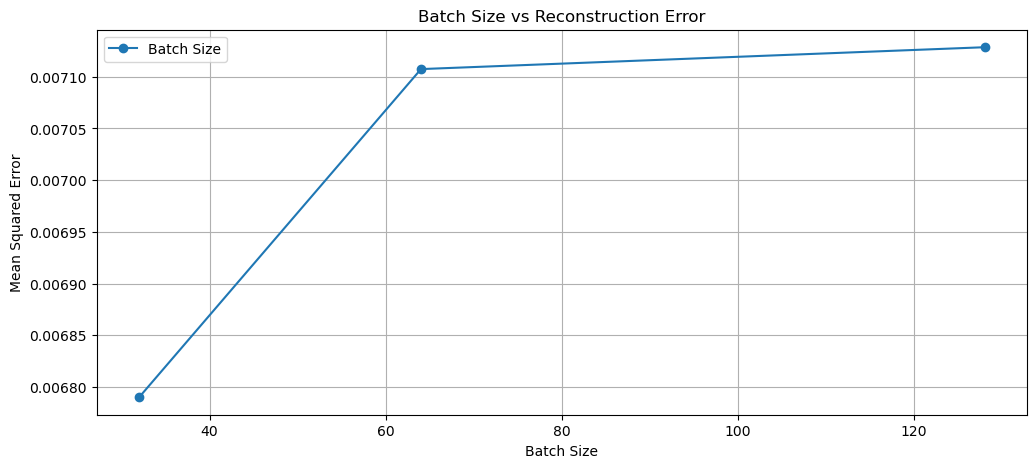

In [20]:
# get mean squared error for each image
batch_size_errors = [np.mean(errors) for errors in batch_size_errors]
# Plot results
plt.figure(figsize=(12, 5))
plt.plot(batch_sizes, batch_size_errors, marker='o', label='Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Mean Squared Error')
plt.title('Batch Size vs Reconstruction Error')
plt.legend()
plt.grid(True)

Training with learning rate: 0.001
Epoch [1/10], Loss: 0.0260
Epoch [2/10], Loss: 0.0133
Epoch [3/10], Loss: 0.0111
Epoch [4/10], Loss: 0.0097
Epoch [5/10], Loss: 0.0089
Epoch [6/10], Loss: 0.0084
Epoch [7/10], Loss: 0.0079
Epoch [8/10], Loss: 0.0076
Epoch [9/10], Loss: 0.0073
Epoch [10/10], Loss: 0.0071
Training with learning rate: 0.005
Epoch [1/10], Loss: 0.0247
Epoch [2/10], Loss: 0.0131
Epoch [3/10], Loss: 0.0110
Epoch [4/10], Loss: 0.0096
Epoch [5/10], Loss: 0.0088
Epoch [6/10], Loss: 0.0083
Epoch [7/10], Loss: 0.0079
Epoch [8/10], Loss: 0.0075
Epoch [9/10], Loss: 0.0073
Epoch [10/10], Loss: 0.0070
Training with learning rate: 0.01
Epoch [1/10], Loss: 0.0261
Epoch [2/10], Loss: 0.0132
Epoch [3/10], Loss: 0.0108
Epoch [4/10], Loss: 0.0095
Epoch [5/10], Loss: 0.0088
Epoch [6/10], Loss: 0.0082
Epoch [7/10], Loss: 0.0078
Epoch [8/10], Loss: 0.0075
Epoch [9/10], Loss: 0.0072
Epoch [10/10], Loss: 0.0069


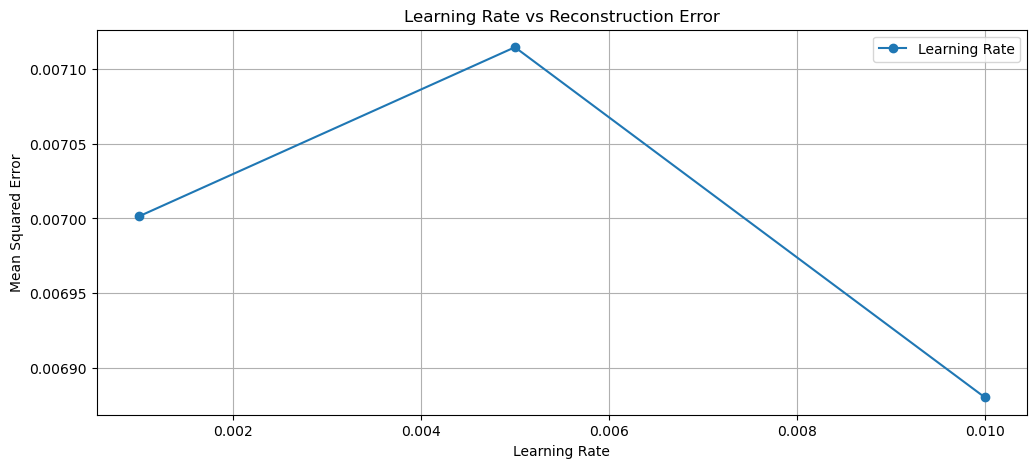

In [21]:
learning_rates = [0.001, 0.005, 0.01]
num_epochs = 10
# Vary learning rate
for lr in learning_rates:
    print(f"Training with learning rate: {lr}")
    model = Autoencoder()
    model = train_autoencoder(model, noisy_trainloader, original_trainloader, num_epochs=num_epochs)
    error = test_autoencoder(model, noisy_testloader, original_testloader)
    learning_rate_errors.append(error)

# get mean squared error for each image
learning_rate_errors = [np.mean(errors) for errors in learning_rate_errors]

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(learning_rates, learning_rate_errors, marker='o', label='Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Mean Squared Error')
plt.title('Learning Rate vs Reconstruction Error')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
print(learning_rates)
print(learning_rate_errors)
print(batch_sizes)
print(batch_size_errors)

[0.001, 0.005, 0.01]
[0.0070014894, 0.0071148355, 0.006880123]
[32, 64, 128]
[0.006790172, 0.0071073836, 0.0071285255]


### 2.3 Discussion of results [4 marks]
**2.3a** Describe at least **two** interesting relevant observations from the evaluation results above.

- Learning Rate: The values (0.001, 0.005, and 0.01) show a minimal effect on the final error metrics, with the error values being extremely close to each other: 0.0070014894, 0.0071148355, and 0.006880123 respectively. This suggests that the model is relatively stable with respect to changes in the learning rate within this range. It indicates that the autoencoder is not highly sensitive to small variations in the learning rate in the range tested. This stability is often seen in models with appropriate weight initialization and architectures that do not require very fine-tuned learning rates. Though the learning rate of 0.01 shows a slightly lower error, and hence is considered the best choice. 
- The batch sizes 32, 64, and 128 lead to errors of 0.006790172, 0.0071073836, and 0.0071285255, respectively. There is a slight increase in error as the batch size increases, particularly between 32 (best) and 64 or 128. This suggests that smaller batch sizes might be providing more accurate updates to the model weights, likely due to more frequent updates during training. It is possible that with larger batch sizes, the updates become less frequent and the optimization might become slightly less responsive to small changes, leading to a marginal increase in error.